# **SC1003 GROUP PROJECT**

**Done by:**

KHOO TENG SUAN, HEIDI (hkhoo002@e.ntu.edu.sg)

KIT HOI MUN, ERICA (kith0002@e.ntu.edu.sg)

KOA YU XUAN (koay0019@e.ntu.edu.sg)

KWOK KIT LEUNG, TERRENCE (tkwok002@e.ntu.edu.sg)

LEE SHI QI, VALENCIA (lees0216@e.ntu.edu.sg)

# **INTRODUCTION**

We will be organising 6000 students into teams of five, ensuring that each team only consists of students from the same tutorial group. The selection of students into each team is weighted across the following three factors, listed in order of priority:

(1) Gender

(2) Current CGPA

(3) School affiliation

We will be forming teams that are balanced across each factor as evenly as possible. In other words, each team has to consist of students from different schools, maintain a healthy mix of male and female students, and avoid a concentration of students with only high/low GPAs.

While it is unfeasible to achieve a perfect mix where every team has the same gender ratio, mean CGPA and school representation, we aim to push to this goal as much as possible by considering the above three factors in the listed order of importance.

**For the final distribution of teams, we aim to satisfy the following targets:**

(1) 90% of all teams having a gender composition of 3 males and 2 females OR 2 males and 3 females

(2) 75% of all teams having a mean CGPA within 1 standard deviation from the overall mean CGPA of all 6000 students

(3) 90% of all teams having representation from at least four different schools per team



**To achieve this, our program involves the following key steps.**

(1) **Parsing the data** - reading and storing all 6000 students' details from the given CSV file records.csv, separated by tutorial group

(2) **Achieving gender/CGPA diversity**- sorts students to maximise gender diversity and CGPA diversity in each team

(3) **Achieving school diversity** - sorts students to maximise school diversity in each team

(4) **Generating output** - exporting the final team assignments into a new CSV file, team_assignments_csv

# **FLOWCHART**

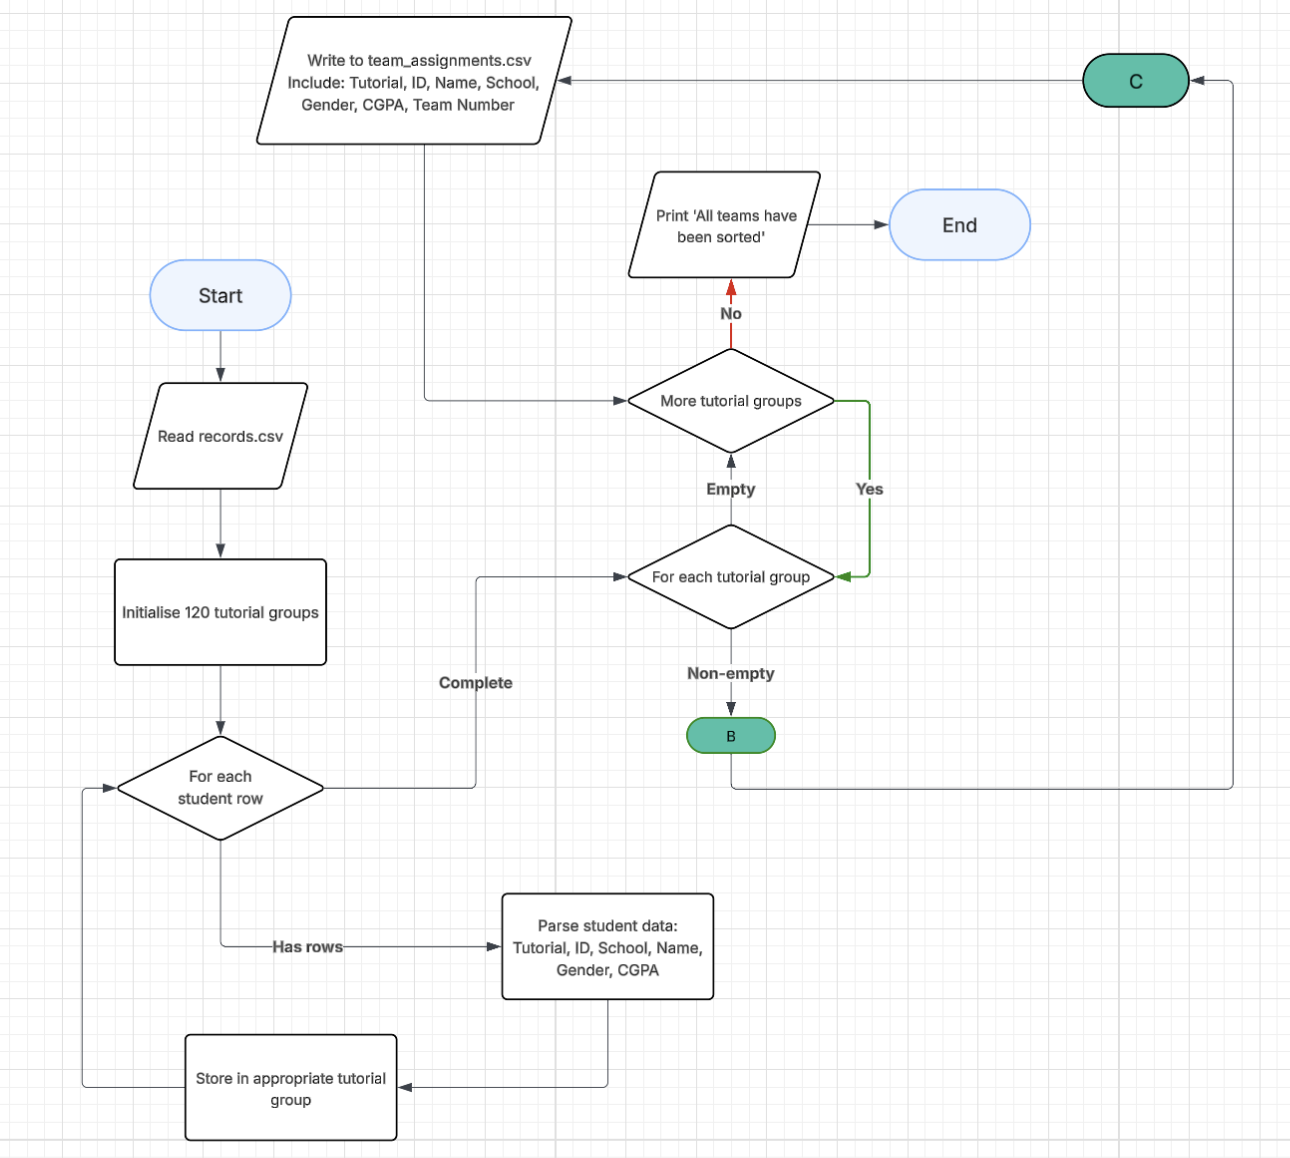

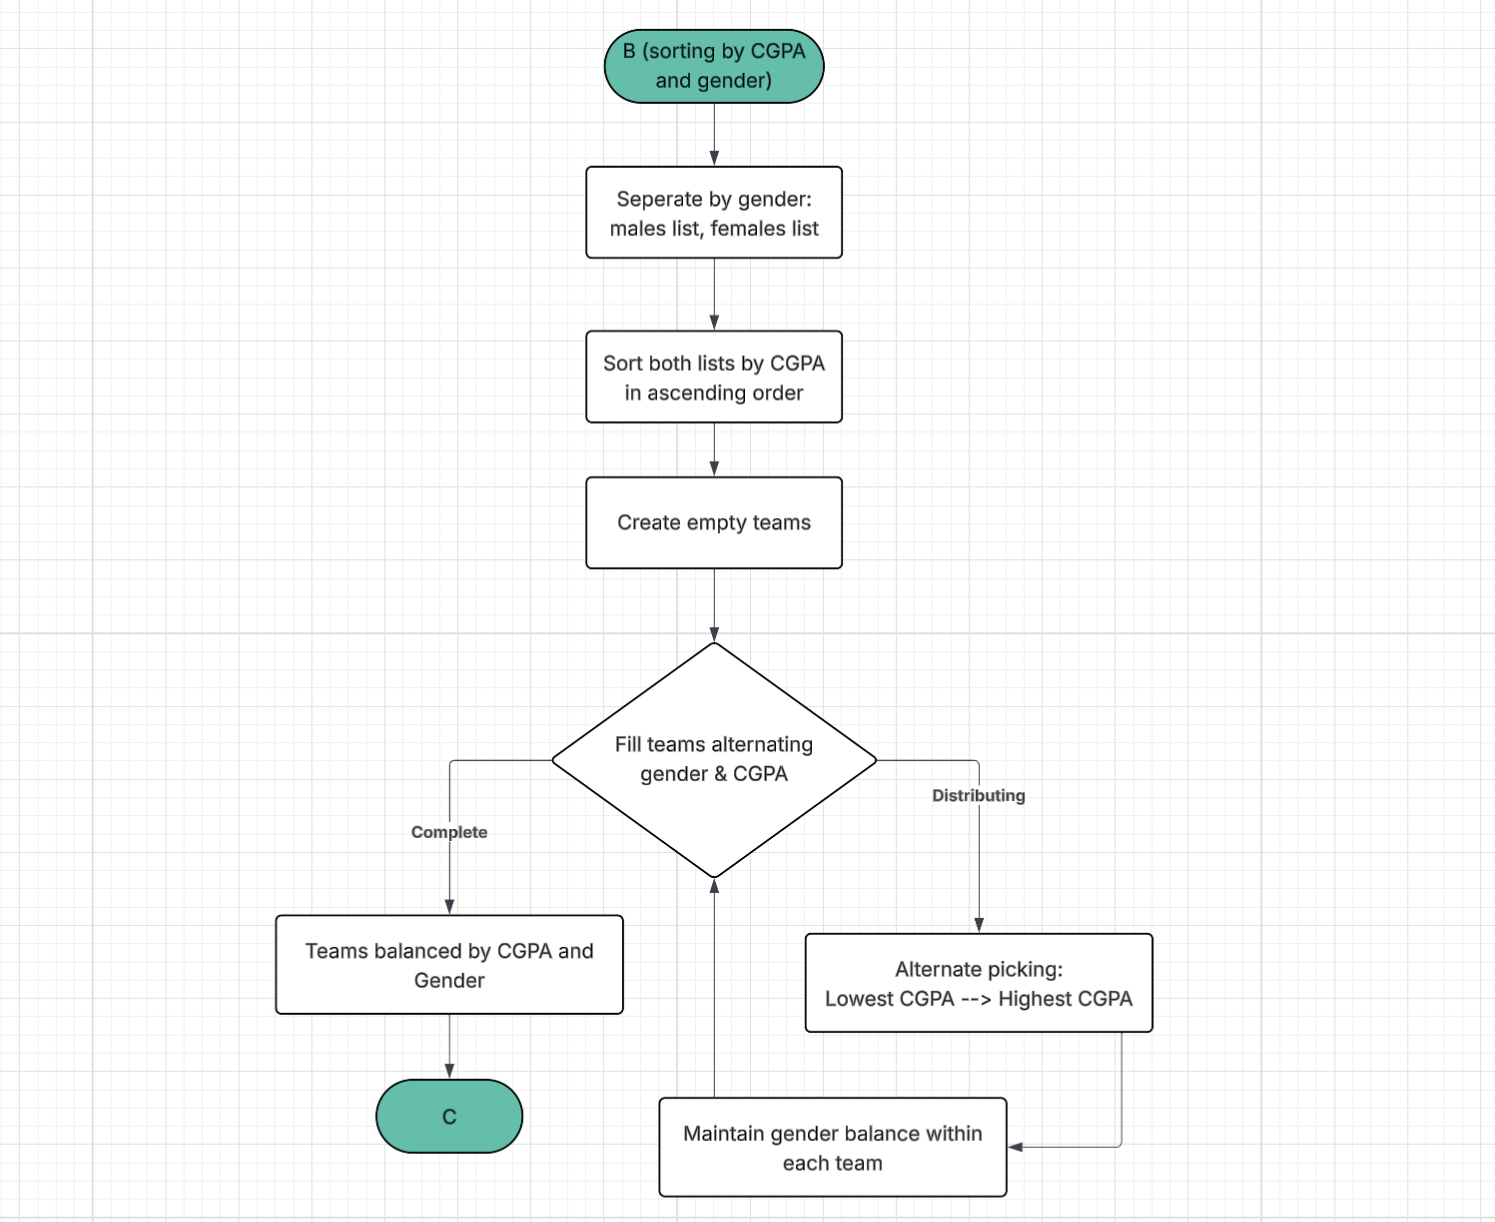

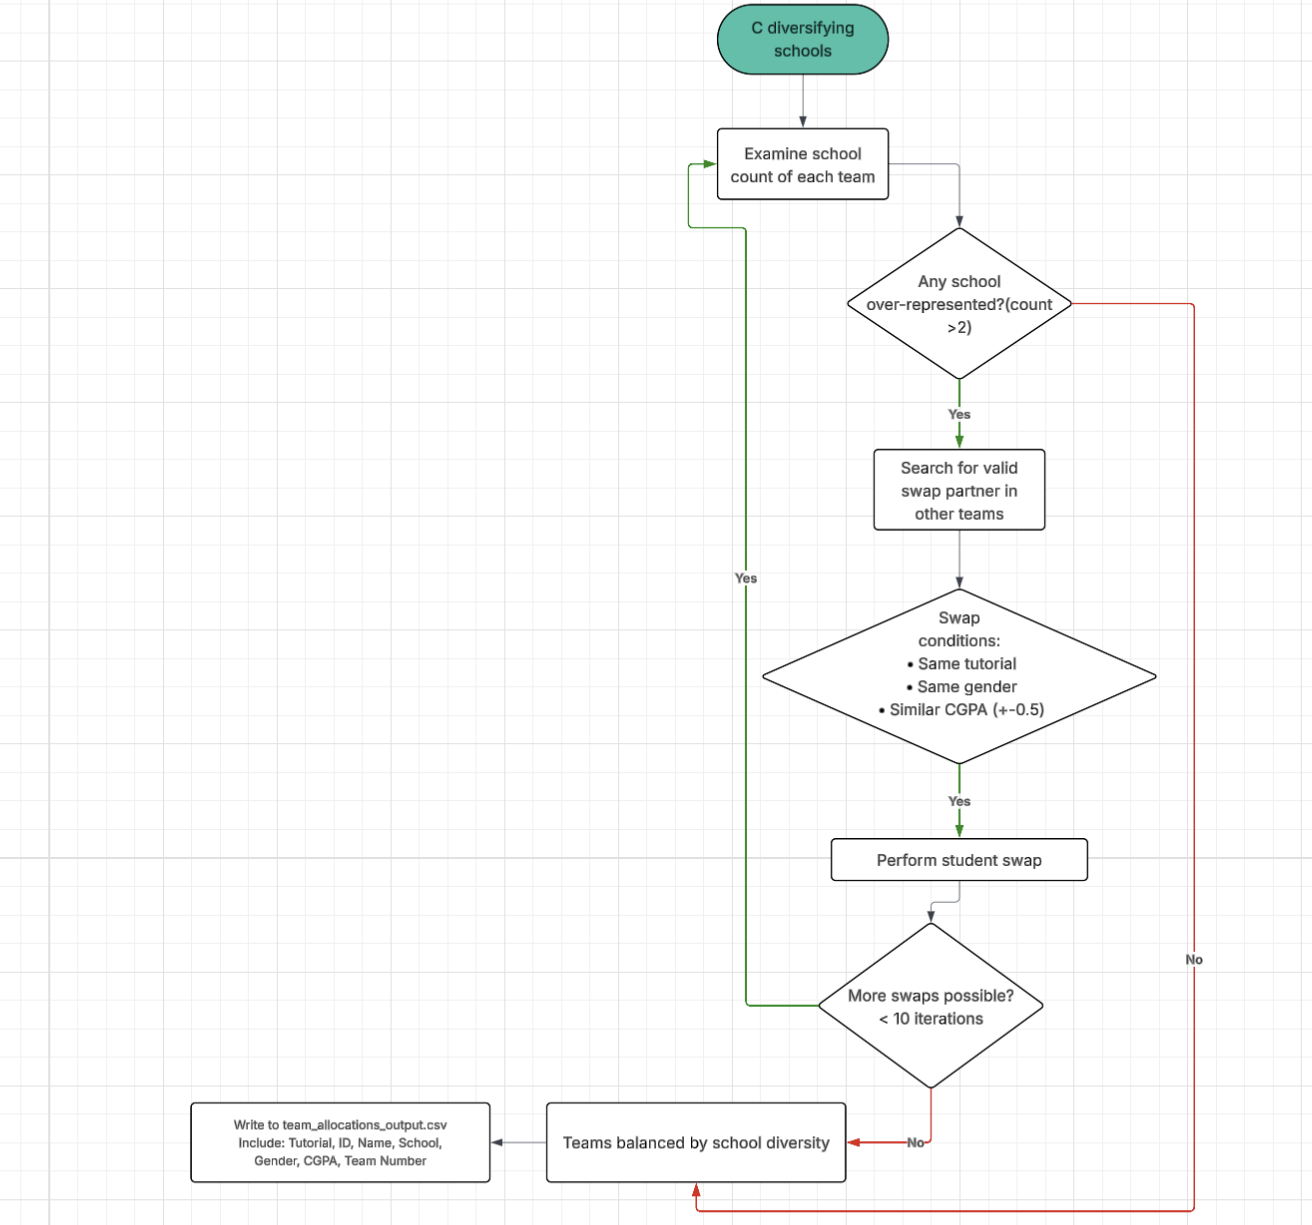

# **SET-UP**

Importing packages

In [ ]:
import matplotlib.pyplot as plt # We import matplotlib as our main method of showing our graphical analysis
import csv  # We will import csv to read our imported files
import math # We will import math so that we can create normal distribution functions for macro analysis

Reading the records.csv file

In [ ]:
recordsFile=open("records.csv", "r")
team_size = 5                         # The number of people in each team
count = 0                             # Initialising a counter to process the rows and their row data
detailList = []
tutList = [ [] for i in range(120)]   # Creating a list to contain 120 lists for each tutorial group

with open('records.csv', "r") as r:
  records = r.read().split("\n")      # Combine all the rows into a list
for r in range(len(records)):
  records[r] = records[r].split(",")  # Split each row into its respective columns
header = records.pop(0)               # Remove header row and save it only when we are exporting at the end
records.pop()                         # Used to remove last row, since it is [''] and there is no data in the next row


['']

Splitting the data into lists for analysis

In [ ]:
# Next, we have to extract the student's tutorial group, school, gender, and grade point average (GPA) extract
tutorial_groups = [tutorial[0] for tutorial in records]
school = [school[2] for school in records]
gender = [gender[4] for gender in records]
gpa = [float(gpa[5]) for gpa in records]

**Now that all relevant data has been extracted from records.csv, we are in a better position to explore the data distribution with regards to gender, CGPA, and school affliation separately.**

### **Gender**




Based on this count plot, the number of males and females is relatively even. That said, there are 482 more females than males. By nature, we will be able to get a balanced group with 2/3 males and females in each group, depending on the ratio in the tutorial groups themselves.

The most likely group ratio will hence be 3 females to 2 males, followed by 2 females to 3 males, followed by 4 females to 1 male.

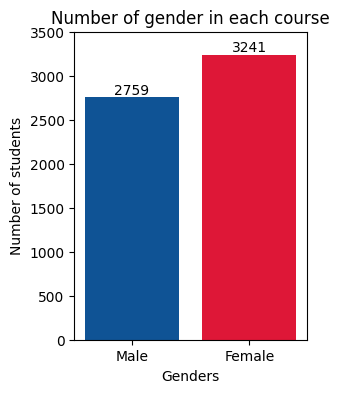

In [ ]:
# Create the plot dimensions
fig, ax = plt.subplots(figsize = (3, 4))

# Count the number of males and females respectively
categories = list(set(gender))  # We use gender so that we can get only unique values
counts = [gender.count(Male_Female) for Male_Female in categories]

# Create the bar plot
# Standardised Blue and Red for males and females respectively
bars = ax.bar(categories, counts , color = ["#0F5395", "#DE1737"])

# Set the x-axis, y-axis, y-limit, bar labels, and title
ax.set_xlabel("Genders")
ax.set_ylabel("Number of students")
ax.set_ylim(0,3500)
ax.bar_label(bars)
ax.set_title("Number of gender in each course")

# Display the plot
plt.show()

### **CGPA**


We can also take a look at CGPA. Based on the histogram below, most of the students have a CGPA within 4.0 to 4.2 This is the range and average CGPA we would expect to achieve within each group.

There are several outliers, such as a maximum of nearly 4.97, and a minimum of 3.7. To counter this, within each tutorial group, we will mix students with 'extremely' high and 'extremely' low CGPAs together.

/tmp/ipython-input-988462956.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())


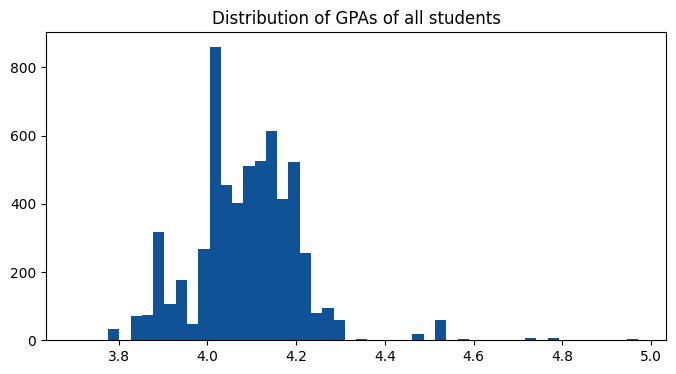

The highest GPA in the data is 4.97
The lowest GPA in the data is 3.7


In [ ]:
# Create the plot dimensions
fig, ax = plt.subplots(figsize = (8,4))

# Create the histogram with bins and color
ax.hist(gpa, bins = 50 , color = ["#0F5396"])

# Set the x-ticks, and title
ax.set_xticklabels(ax.get_xticklabels())
ax.set_title("Distribution of GPAs of all students")

# Display the plot
plt.show()

# Extra analysis on the min/max of the data
print(f"The highest GPA in the data is {max(gpa)}")
print(f"The lowest GPA in the data is {min(gpa)}")

### **School**

The last factor to consider is school affiliation. There is a large number of students, particularly from CCDS, EEE, CoB(NBS).

This would imply that more emphasis would be needed to split these students amongst other schools.

The other schools with a higher distribution includes MAE, SSS and CCEB.

/tmp/ipython-input-713504502.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation = 45 ,ha = 'right')


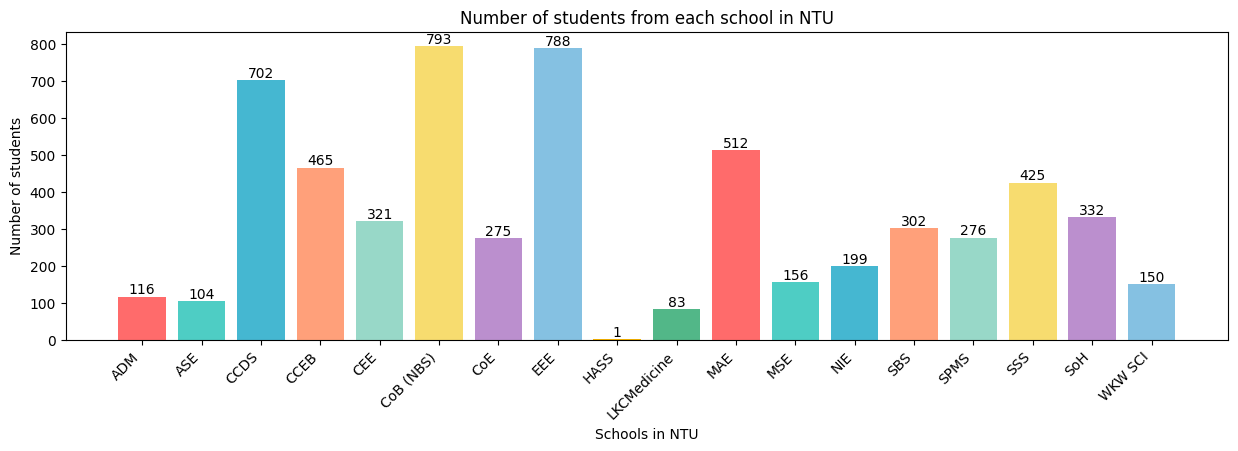

In [ ]:
# Create the plot dimensions
fig , ax = plt.subplots( figsize = (15,4))

# Create a list containing each unique school
categories = list(set(school))
categories.sort()
counts = [school.count(colleges) for colleges in categories]

# Create the bar chart
bars = ax.bar(categories, counts , color = [ '#FF6B6B' , '#4ECDC4' ,'#45B7D1',
                                            '#FFA07A', '#98D8C8', '#F7DC6F',
                                             '#BB8FCE', '#85C1E2', '#F8B400',
                                             '#52B788'])
# Label the number of students from each bar
ax.bar_label(bars)

# Set the x-axis, y-axis, and title
ax.set_xlabel("Schools in NTU")
ax.set_ylabel("Number of students")
ax.set_title("Number of students from each school in NTU")
ax.set_xticklabels(categories, rotation = 45 ,ha = 'right')

# Display the plot
plt.show()

# **PROGRAM BREAKDOWN**

## **Parsing of data (Erica)**

**When parasing the data, the code should:**

*   Group the students according to their tutorial groups
*   Include the student's particular which includes Tutorial group, Student ID, School, Name, Gender and CGPA
* creating a function `parsing_student_data(recordsFile)` and using a for loop to go through every student in the records list.
























In [ ]:
import csv

#define the function to parse the data
def parsing_student_data(recordsFile):
    records= open(recordsFile, "r") #opens the record file without changing the file content (r is read only)
    tutorial_grp_list = [[] for i in range(120)] # creates 120 lists each representing a tutorial group contained in the main tutorial_list

    is_header = True # when it first reaches the header row, it is identified as header_row and its boolean value is True
    for row in records:
        if is_header:
          is_header = False # changes the boolean value of the header_row to False
          continue #loops back to the beginning of the for looop and the header row will be skipped

          # for subsequent rows, its boolean value is now False, so it would not be skipped and skips the if condition

        details= row.strip('\n')  # removes '\n' from the text
        student_information = details.split(',')  # the list now contains all the information of the students
        student_information[5]= float(student_information[5]) # CGPA is converted into a float to be used in number operations later

        detail_category= ["Tutorial Group","Student ID","School","Name","Gender","CGPA"]

        student_data={}
        for index in range(len(student_information)):

          student_data[detail_category[index]] = student_information[index]
           # key-value pairs used to add the student's details (The key is the detail_catergory and the value is the detail itself)

        x= student_data["Tutorial Group"].split('-') #splits G and the number eg. 1 from each other

        tutorial_grp_num= int(x[1])- 1 #creates the index of the sub list it will be assignned to

        tutorial_grp_list[tutorial_grp_num].append(student_data)
         # dictionaries of 6000 students contain the student's particulars and are split into 120 lists based off their tutorial groups

    records.close()
    return tutorial_grp_list

## **Achieving Gender and CGPA Diversity (Yu Xuan)**

*   Separate the students out by gender
*   Sort both gender lists in ascending order of the students' CGPA, using the bubble sort function previously defined
*   Create the teams by alternating between male/female students and low/high CGPA values

**Gender alternation**

*   Initialise boolean variable `male_turn` as `True`, so the first student selected for the first team will be a male
*   `male_turn` alternates between `True` and `False` with each subsequent student selected (i.e. with every iteration of the `while` loop) into the subsequent team upon the situation where the team currently has an equal number of males and females (see criteria #3 below).

Gender selection for the subsequent teams will follow the below criteria:

1.   If the team currently has more males, select a female next if available
2.   If the team currently has more females, select a male next if available
3.   If the team currently has an equal number of males and females, alternate based on `male_turn` if available
4.   If one gender list is empty, select the other gender list that has remaining students

*   When both gender lists are empty, all teams have been assigned 5 students each that are well balanced by gender and CGPA. Only then, the `while` loop is broken

**CGPA alternation**

*   Initialise boolean variable `low_CGPA_turn` as `True` whenever a team is created, so the first student selected into any newly created team will have the lowest CGPA of the chosen gender list
*   `low_CGPA_turn` alternates between `True` and `False` with each subsequent student selected (i.e. with every iteration of the `while` loop)
*   The eventual pattern is that the first few teams will consist of students with more extreme CGPAs (be it high or low), while the later few teams will consist of students with CGPAs closer to the global mean CGPA.





In [ ]:
# Bubble sort algorithm used to sort students by CGPA
def bubble_sort_by_cgpa(students):
  # Input: students, a list of dictionaries where each dictionary stores the student's details

  # Determine number of students in the list
  total_students = len(students)

  for i in range(total_students):
  # After each outer loop iteration, the highest CGPA amongst the unsorted students moves to the end
    for j in range(0, total_students-i-1):
      # Iterating only through the unsorted portion
      # Compares the CGPA of the current student and the next student
      if students[j]["CGPA"] > students[j+1]["CGPA"]:
        students[j], students[j+1] = students[j+1], students[j]
        # Swaps their positions if the current student has a higher CGPA
        # Gradually, students with higher CGPA are pushed towards the end of the list

  # Output: the same list of students but arranged in ascending order of CGPA
  return students

# Distributes students in each tutorial group into ten balanced teams, maintaining gender and CGPA diversity
def optimise_gender_CGPA_diversity(tutorial_grp):
  # Input:
  # tutorial_grp, a list of dictionaries where each dictionary contains each student's
  # (1) Tutorial group, (2) Student ID, (3) School, (4) Name, (5) Gender, and (6) CGPA as keys.
  # In this function, only the students' gender and CGPA are considered for sorting.

  # Firstly, separate students by gender
  male_students = [student for student in tutorial_grp if student["Gender"] == "Male"]
  female_students = [student for student in tutorial_grp if student["Gender"] == "Female"]

  # Sort both groups of males and females by CGPA, using the above function
  bubble_sort_by_cgpa(male_students)
  bubble_sort_by_cgpa(female_students)

  # Create teams based on the number of students in the tutorial group
  # Assuming 50 students per tutorial group, this will create 10 teams of 5
  num_teams = len(tutorial_grp) // 5
  teams = [[] for i in range(num_teams)]

  # First person to be selected will be a male. Gender will be alternated (as shown later)
  male_turn = True

  # Track which team is currently being filled
  team_index = 0

  # Each team gets a True or False boolean variable for whether the student selected should have low CGPA
  low_CGPA_turns = [True] * num_teams

  # While loop continues until no one is left in the male or female list
  while male_students or female_students:
    # Check if all teams already have 5 members
    all_full = True
    for team in teams:
      if len(team) < 5: # Team is not yet full
        all_full = False
        break # Exit the for loop if there is a single team that has less than 5 members
    if all_full:
      break # Exit the while loop if every team is completely filled, otherwise the below code will continue to run

    # Skip to next team if current team already has 5 members
    while len(teams[team_index]) >= 5:
      team_index = (team_index + 1) % num_teams  # Cycle back to 0 when team_index reaches num_teams-1

    # Select the lowest CGPA in the chosen gender list when considering the first student for a new team
    if len(teams[team_index]) == 0:
      low_CGPA_turns[team_index] = True

    # Count number of male and female students in the current team index
    count_males_in_team = sum(1 for student in teams[team_index] if student["Gender"] == "Male")
    count_females_in_team = sum(1 for student in teams[team_index] if student["Gender"] == "Female")

    # ================
    # Gender selection
    # ================

    # (1) If the team currently has more males, select a female next if available
    # (2) If the team currently has more females, select a male next if available
    # (3) If the team currently has an equal number of males and females, alternate based on male_turn if available
    # (4) If one gender list is empty, select the other gender list that has remaining students

    if count_males_in_team > count_females_in_team and female_students: # (1)
        chosen_list = female_students
    elif count_females_in_team > count_males_in_team and male_students: # (2)
        chosen_list = male_students
    elif male_turn and male_students: # (3)
        chosen_list = male_students
    elif not male_turn and female_students: # (3)
        chosen_list = female_students
    elif male_students: # (4)
        chosen_list = male_students
    elif female_students: # (4)
        chosen_list = female_students
    else: # No more unassigned students in the tutorial group, i.e. both gender lists are empty
        break

    # ================
    # CGPA alternation
    # ================

    # Within the chosen gender list, alternate between lowest and highest CGPA
    if low_CGPA_turns[team_index]:
      student = chosen_list.pop(0) # Student with lowest CGPA selected
    else:
      student = chosen_list.pop(-1) # Student with highest CGPA selected
    low_CGPA_turns[team_index] = not low_CGPA_turns[team_index] # Flip CGPA alternation for the next student selected within the same team

    # Add the selected student to the current team
    teams[team_index].append(student)

    # Flip gender alternation for the next student selected into the next team
    male_turn = not male_turn

    # After adding the student to the current team, move on to the next team
    # Similar to a previous line of code, cycle back to 0 when team_index reaches num_teams-1
    team_index = (team_index + 1) % num_teams

  # Output: a list of sublists, where each sublist is a team that has been balanced by gender and CGPA
  return teams

## **Achieving School Diversity (Heidi)**

* Check and fix school diversity issues in each team
* For loop will run through each team and count the frequency of each school in the current team
* An empty dictionary ```schools``` is created to store the frequency of how many time each school appears
* School is the key and the number of times the school appears in the team is the value
* If there are over-represented schools found within a team (more than 2 students from same school), those students will be swapped with students from another team with full members
* Count the school distribution in the team being considered for a swap
* Student 1 is from the over-represented school in the current team
* Student 2 is a student from another team to be swapped with student 1

**Criteria for swapping**

1) Student 1 and Student 2 should be from the same tutorial group
2) Student 2 shouldn't be from the same school as Student 1
3) Student 2's school shouldn't already have 2 or more students in Student 1's team
4) Student 1's school shouldn't create over-representation (>2) in Student 2's team
5) Student 1 and Student 2 should be of same gender
6) Student 1 and Student 2 should have similar CGPA (difference ≤ 0.5)

* After swapping, break from the inner loop
* Continue replacing over-represented schools until no more valid swaps can be made
* Maximum of 10 iterations to prevent infinite loops
* If no student is found which meets the criteria above, no swap will be performed (retains diversity of gender and CGPA)

In [ ]:
# check and fix school diversity issues in each team
def optimise_school_diversity(teams):
  for i in range(len(teams)):
    if len(teams[i]) == 5:  # only process full teams
        # keep trying to improve diversity until no more swaps are possible
        swap_made = True
        max_iterations = 10  # prevent infinite loops
        iteration_count = 0

        while swap_made and iteration_count < max_iterations:
            swap_made = False
            iteration_count += 1

            # count frequency of each school in each/current team
            schools = {}
            for student in teams[i]:
                school = student["School"] #refer to student data dict

                # check if this school has been seen before
                if school in schools:
                    # school exists, increment the count
                    schools[school] = schools[school] + 1
                else:
                    # first time seeing this school, set count to 1
                    schools[school] = 1
                    ## eg. schools = {"CCDS":3, "SSS":1, "SPMS":1}

            # check each school for over-representation (more than 2 students)
            for school in schools:
                if schools[school] > 2:
                  # try to swap with students from other teams
                    for j in range(len(teams)):
                        if i != j and len(teams[j]) == 5:
                            # count schools in other team
                            other_schools = {}
                            for other_student in teams[j]:
                                other_school = other_student["School"]
                                if other_school in other_schools:
                                    other_schools[other_school] += 1
                                else:
                                    other_schools[other_school] = 1

                            # find student to swap from team i
                            for si in range(len(teams[i])):
                                student1 = teams[i][si]

                                # only swap students from over-represented school
                                if student1["School"] != school:
                                    continue

                                # find swap partner in team j
                                for sj in range(len(teams[j])):
                                    student2 = teams[j][sj]

                                    cgpa_diff = abs(student1["CGPA"] - student2["CGPA"])

                                    # SWAP CONDITIONS (in priority order):
                                    # 1. same tutorial group
                                    # 2. different school
                                    # 3. student2's school not already in team i
                                    # 4. student2's school will not be over-represented in team i
                                    # 5. student1's school will not be over-represented in team j
                                    # 6. same gender (Preserve gender balance)
                                    # 7. similar CGPA (Preserve CGPA balance)

                                    if (student1["Tutorial Group"] == student2["Tutorial Group"] and
                                        student2["School"] != school and
                                        (student2["School"] not in schools or schools[student2["School"]] < 2) and
                                        (student1["School"] not in other_schools or other_schools[student1["School"]] < 2) and
                                        student1["Gender"] == student2["Gender"] and
                                        cgpa_diff <= 0.5):

                                        # Perform swap
                                        teams[i][si], teams[j][sj] = teams[j][sj], teams[i][si]
                                        swap_made = True
                                        break

                                if swap_made:
                                    break

                        if swap_made:
                            break

                if swap_made:
                    break
  return teams

## **Integrating both stages**

* This function acts as the master function to integrate the gender/CGPA diversity function and the school diversity function
* It will first call `optimise_gender_CGPA_diversity` to form gender balanced and CGPA balanced teams. The resulting teams will be input into `optimise_school_diversity` for school representation to generate the final teams

In [ ]:
def generate_balanced_teams(tutorial_grp):
   stage1 = optimise_gender_CGPA_diversity(tutorial_grp)
   final_teams = optimise_school_diversity(stage1)
   return final_teams

## **Generating output (Erica)**

**To generate the output of the teams:**

*   Open a new file with `w` to create a new file to write in
*   create a list of column headers with the type of student detail
*   Using `.writerow` to write down all column headers
*   Using parasing_student_data("records.csv"), it open and extract the student data from the records file.
*   Using a for loop and generate_balanced_teams(tutorial_grp)  to generate teams within each tutorial group
*  Adding a new key-value pair to the dictionary containing the student's data with 'Team Assigned' and 'team_numbers[j]"




In [ ]:
file= open('team_assignments.csv', 'w', newline='', encoding='utf-8')
# opens file object team_assignments and creates a new file with default encoding utf-8 (storing characters)
# newline='' writes the data out as it is
writer = csv.writer(file)
# csv.writer() writes data directly from the file into the new file, team_assignments

column_headers= ['Tutorial Group','Student ID', 'School','Name','Gender', 'CGPA', 'Team Assigned']

#Writes all the headers in
writer.writerow(column_headers)

tutorialList = parsing_student_data("records.csv") #parasing the student data from the records file

for tutorial_grp in tutorialList:

  # sorts each tutorial group into groups of 5 using the eariler function
  teams = generate_balanced_teams(tutorial_grp)

  # len(teams) counts the number of teams
  # range(1,len(teams) + 1) creates a range of numbers starting from 1 and includes the last team number
  # utilising list comprehension with for statement to list every team number in the list
  team_numbers = [i for i in range(1, len(teams) + 1)]

  # for loop for the indexs of all teams (sublist) in the teams
  for j in range(len(teams)):

    # assigning each student their team number under "Team_Assigned" and adds a new key-value pair to the student dictionary
    for student in teams[j]:
        student["Team Assigned"] = team_numbers[j]

        # creating a list of all the types of details to retrieve for each student in the current team
        detail_catergories= ['Tutorial Group','Student ID', 'School','Name','Gender', 'CGPA', 'Team Assigned']

        # using .get to retrieve each student detail for each catergory in the student dictionary in the sublist
        student_details = [str(student.get(detail)) for detail in detail_catergories]

        writer.writerow(student_details) # writes out all the student's details in each catergory

file.close()
print("All teams have been sorted")

All teams have been sorted


# **FINAL CODE - ALL TOGETHER**

In [ ]:
# ===============
# parsing of data
# ===============

import csv

def parsing_student_data(recordsFile):
    records= open(recordsFile, "r")
    tutorial_grp_list = [[] for i in range(120)] #  creates 120 lists each representing a tutorial group is contained in the list tutorial_list

    is_header = True # when it first reaches the header row, it is identified as header_row and its boolean value is True
    for student_info in records:
        if is_header:
          is_header = False # changes the boolean value of the header_row to False
          continue #loops back to the beginning of the for looop and the header row will be skipped

          # for subsequent rows, it's boolean value is now False, so it would not be skipped and skip the if condition

        student_particular= student_info.strip('\n')  # removes '\n' from the text
        student_information = student_particular.split(',')  # the list now contains all the information of the students
        student_information[5]= float(student_information[5]) # CGPA is converted into a float to be used in number operations later

        detail_category= ["Tutorial Group","Student ID","School","Name","Gender","CGPA"]

        student_data={}
        for j in range(len(student_information)):

          student_data[detail_category[j]] = student_information[j]
           # key-value pairs used to add the student's details (The key is the detail_catergory and the value is the detail itself)

        x= student_data["Tutorial Group"].split('-') #splits G and the number eg. 1 from each other

        tutorial_grp_num= int(x[1])- 1 #creates the index of the sub list it will be assignned to

        tutorial_grp_list[tutorial_grp_num].append(student_data)
         # dictionaries of 6000 students contain the student's particulars and are split into 120 lists based off their tutorial groups

    records.close()
    return tutorial_grp_list


# ===================================
# achieving gender and CGPA diversity
# ===================================

# Bubble sort algorithm used to sort students by CGPA
def bubble_sort_by_cgpa(students):
  # Input: students, a list of dictionaries where each dictionary stores the student's details

  # Determine number of students in the list
  total_students = len(students)

  for i in range(total_students):
  # After each outer loop iteration, the highest CGPA amongst the unsorted students moves to the end
    for j in range(0, total_students-i-1):
      # Iterating only through the unsorted portion
      # Compares the CGPA of the current student and the next student
      if students[j]["CGPA"] > students[j+1]["CGPA"]:
        students[j], students[j+1] = students[j+1], students[j]
        # Swaps their positions if the current student has a higher CGPA
        # Gradually, students with higher CGPA are pushed towards the end of the list

  # Output: the same list of students but arranged in ascending order of CGPA
  return students

# Distributes students in each tutorial group into ten balanced teams, maintaining gender and CGPA diversity
def optimise_gender_CGPA_diversity(tutorial_grp):
  # Input:
  # tutorial_grp, a list of dictionaries where each dictionary contains each student's
  # (1) Tutorial group, (2) Student ID, (3) School, (4) Name, (5) Gender, and (6) CGPA as keys.
  # In this function, only the students' gender and CGPA are considered for sorting.

  # Firstly, separate students by gender
  male_students = [student for student in tutorial_grp if student["Gender"] == "Male"]
  female_students = [student for student in tutorial_grp if student["Gender"] == "Female"]

  # Sort both groups of males and females by CGPA, using the above function
  bubble_sort_by_cgpa(male_students)
  bubble_sort_by_cgpa(female_students)

  # Create teams based on the number of students in the tutorial group
  # Assuming 50 students per tutorial group, this will create 10 teams of 5
  num_teams = len(tutorial_grp) // 5
  teams = [[] for i in range(num_teams)]

  # First person to be selected will be a male. Gender will be alternated (as shown later)
  male_turn = True

  # Track which team is currently being filled
  team_index = 0

  # Each team gets a True or False boolean variable for whether the student selected should have low CGPA
  low_CGPA_turns = [True] * num_teams

  # While loop continues until no one is left in the male or female list
  while male_students or female_students:
    # Check if all teams already have 5 members
    all_full = True
    for team in teams:
      if len(team) < 5: # Team is not yet full
        all_full = False
        break # Exit the for loop if there is a single team that has less than 5 members
    if all_full:
      break # Exit the while loop if every team is completely filled, otherwise the below code will continue to run

    # Skip to next team if current team already has 5 members
    while len(teams[team_index]) >= 5:
      team_index = (team_index + 1) % num_teams  # Cycle back to 0 when team_index reaches num_teams-1

    # Select the lowest CGPA in the chosen gender list when considering the first student for a new team
    if len(teams[team_index]) == 0:
      low_CGPA_turns[team_index] = True

    # Count number of male and female students in the current team index
    count_males_in_team = sum(1 for student in teams[team_index] if student["Gender"] == "Male")
    count_females_in_team = sum(1 for student in teams[team_index] if student["Gender"] == "Female")

    # ================
    # Gender selection
    # ================

    # (1) If the team currently has more males, select a female next if available
    # (2) If the team currently has more females, select a male next if available
    # (3) If the team currently has an equal number of males and females, alternate based on male_turn if available
    # (4) If one gender list is empty, select the other gender list that has remaining students

    if count_males_in_team > count_females_in_team and female_students: # (1)
        chosen_list = female_students
    elif count_females_in_team > count_males_in_team and male_students: # (2)
        chosen_list = male_students
    elif male_turn and male_students: # (3)
        chosen_list = male_students
    elif not male_turn and female_students: # (3)
        chosen_list = female_students
    elif male_students: # (4)
        chosen_list = male_students
    elif female_students: # (4)
        chosen_list = female_students
    else: # No more unassigned students in the tutorial group, i.e. both gender lists are empty
        break

    # ================
    # CGPA alternation
    # ================

    # Within the chosen gender list, alternate between lowest and highest CGPA
    if low_CGPA_turns[team_index]:
      student = chosen_list.pop(0) # Student with lowest CGPA selected
    else:
      student = chosen_list.pop(-1) # Student with highest CGPA selected
    low_CGPA_turns[team_index] = not low_CGPA_turns[team_index] # Flip CGPA alternation for the next student selected within the same team

    # Add the selected student to the current team
    teams[team_index].append(student)

    # Flip gender alternation for the next student selected into the next team
    male_turn = not male_turn

    # After adding the student to the current team, move on to the next team
    # Similar to a previous line of code, cycle back to 0 when team_index reaches num_teams-1
    team_index = (team_index + 1) % num_teams

  # Output: a list of sublists, where each sublist is a team that has been balanced by gender and CGPA
  return teams


# ==========================
# achieving school diversity
# ==========================

# Check and fix school diversity issues in each team
def optimise_school_diversity(teams):
  for i in range(len(teams)):
    if len(teams[i]) == 5:  # Only process full teams
        # Keep trying to improve diversity until no more swaps are possible
        swap_made = True
        max_iterations = 10  # Prevent infinite loops
        iteration_count = 0

        while swap_made and iteration_count < max_iterations:
            swap_made = False
            iteration_count += 1

            # Count frequency of each school in current team
            schools = {}
            for student in teams[i]:
                school = student["School"]

                # Check if this school has been seen before
                if school in schools:
                    # School exists, increment the count
                    schools[school] = schools[school] + 1
                else:
                    # First time seeing this school, set count to 1
                    schools[school] = 1

            # Check each school for over-representation (more than 2 students)
            for school in schools:
                if schools[school] > 2:
                    # Try to swap with students from other teams
                    for j in range(len(teams)):
                        if i != j and len(teams[j]) == 5:
                            # Count schools in other team
                            other_schools = {}
                            for other_student in teams[j]:
                                other_school = other_student["School"]
                                if other_school in other_schools:
                                    other_schools[other_school] += 1
                                else:
                                    other_schools[other_school] = 1

                            # Find student to swap from team i
                            for si in range(len(teams[i])):
                                student1 = teams[i][si]

                                # Only swap students from over-represented school
                                if student1["School"] != school:
                                    continue

                                # Find swap partner in team j
                                for sj in range(len(teams[j])):
                                    student2 = teams[j][sj]

                                    cgpa_diff = abs(student1["CGPA"] - student2["CGPA"])

                                    # SWAP CONDITIONS (in priority order):
                                    # 1. Same tutorial group
                                    # 2. Different school
                                    # 3. Student2's school not already in team i
                                    # 4. Student2's school will not be over-represented in team i
                                    # 5. Student1's school will not be over-represented in team j
                                    # 6. Same gender (Preserve gender balance)
                                    # 7. Similar CGPA (Preserve CGPA balance)

                                    if (student1["Tutorial Group"] == student2["Tutorial Group"] and
                                        student2["School"] != school and
                                        (student2["School"] not in schools or schools[student2["School"]] < 2) and
                                        (student1["School"] not in other_schools or other_schools[student1["School"]] < 2) and
                                        student1["Gender"] == student2["Gender"] and
                                        cgpa_diff <= 0.5):

                                        # Perform swap
                                        teams[i][si], teams[j][sj] = teams[j][sj], teams[i][si]
                                        swap_made = True
                                        break

                                if swap_made:
                                    break

                        if swap_made:
                            break

                if swap_made:
                    break
  return teams


# ================================================================
# additional master function to integrate our previously separated
# gender/CGPA diversity and school diversity functions
# ================================================================

def generate_balanced_teams(tutorial_grp):
   stage1 = optimise_gender_CGPA_diversity(tutorial_grp)
   final_teams = optimise_school_diversity(stage1)
   return final_teams

# =================
# generating output
# =================

file= open('team_assignments.csv', 'w', newline='', encoding='utf-8') #write the comment about w and the encoding
writer = csv.writer(file)

column_headers= ['Tutorial Group','Student ID' ,'Name', 'School', 'Gender', 'CGPA', 'Team Assigned']

#Writes all the headers in
writer.writerow(column_headers)

tutorialList = parsing_student_data("records.csv")

for tutorial_grp in tutorialList:
  teams = generate_balanced_teams(tutorial_grp)
  team_numbers = [i for i in range(1, len(teams) + 1)]

  for j in range(len(teams)):

    # assigning each student their team number under "Team_Assigned"
    for student in teams[j]:
        student["Team Assigned"] = team_numbers[j]

        # creating a list of all the types of details to retrieve for each student in the current team
        detail_catergories= ['Tutorial Group','Student ID' ,'Name', 'School', 'Gender', 'CGPA', 'Team Assigned']

        # using .get to retrieve each student detail for each catergory
        student_details = [str(student.get(detail)) for detail in detail_catergories]

        writer.writerow(student_details) #writes out all the student details in each catergory

file.close()
print("All teams have been sorted")

All teams have been sorted


# **ANALYSIS OF THE GROUPS**

Now we can take a look at the distribution of our groups, based on their gender, school and mean GPA respectively. We will open our new CSV file, and with each column indices, we will loop through each row for each student's information. We will then sort the teams into ascending orders.

In [ ]:
# Read the new CSV file and create variables for each category of data we have
# Use a dictionary to store students based on their team number
students_by_tutorial_and_team = {}
all_students = []               # Store all the students for micro/macro analysis

with open("team_assignments.csv", newline = "" , encoding = "utf-8") as csvfile:
  reader = csv.reader(csvfile)  # Create a CSV reader to iterate through each row
  header = next(reader)         # Read the first header row to identify column indices

  # Find indices for all columns needed
  team_index = header.index("Team Assigned")
  school_index = header.index("School")
  student_id_index = header.index("Student ID")
  name_index = header.index("Name")
  gender_index = header.index("Gender")
  gpa_index = header.index("CGPA")

  # Check if there is a tutorial group that was named differently in the column
  tut_index = None
  for different_names in ["Tutorial Group", "Tutorial", "Tut Group", "Group"] :
    try:
      tut_index = header.index(different_names)
      break
    except ValueError:
      continue


  # Now, loop through each subsequent row for every student's information
  for row in reader:
      team = int(row[team_index])             # Converts team number into integer
      school = row[school_index].strip()      # Remove the leading/trailing spaces
      gender = row[gender_index].strip().lower() # Ensure that gender is in lowercase
      gpa = float(row[gpa_index])             # Convert the GPA string into a float
      student_info = (row[student_id_index], row[name_index], school, gender, gpa)

      # Add all info to the student list
      all_students.append(student_info)

      # Now, we organise them based on tutorial groups and team, assuming they exist
      if tut_index is not None:
        tut_group = row[tut_index].strip()
        if tut_group not in students_by_tutorial_and_team:
          students_by_tutorial_and_team[tut_group] = { }
        if team not in students_by_tutorial_and_team[tut_group]:
          students_by_tutorial_and_team[tut_group][team] = [ ]
        students_by_tutorial_and_team[tut_group][team].append(student_info)
      else:
      # We create a new entry for the team since it does not exist in the dict
        if "default" not in students_by_tutorial_and_team:
          students_by_tutorial_and_team["default"] = { }
        if team not in students_by_tutorial_and_team["default"]:
          students_by_tutorial_and_team["default"][team] = [ ]
        students_by_tutorial_and_team["default"][team].append(student_info)

# Create a flattened structure using composite keys for all teams in each group
students_by_team = { }
for tut_group, teams_dict in students_by_tutorial_and_team.items():
  for team, students in teams_dict.items():
    composite_key = f"{tut_group}_{team}"
    students_by_team[composite_key] = students

# Aside from a macro view of the data, we can also create sturcutre for a single tutorial group
# We can also sort team numbers to ensure that they are in ascending order
first_tut_group = list(students_by_tutorial_and_team.keys())[0]
teams = sorted(students_by_tutorial_and_team[first_tut_group].keys())
groups = [students_by_tutorial_and_team[first_tut_group][team] for team in teams]

# Print the result of each of the variables we created
print(f"Total number of students loaded: {len(all_students)}")
print(f"Total number of teams across all tutorial groups combined: {len(students_by_team)}")
print(f"Total number of tutorial groups found: {len(students_by_tutorial_and_team)}")


Total number of students loaded: 6000
Total number of teams across all tutorial groups combined: 1200
Total number of tutorial groups found: 120


## **DIVERSITY OF SCHOOLS**

We will look at the diversity of schools from a top down and a bottom up approach. The top down involves looking at each team and counting the number of different schools within that team. The bottom up approach involves looking at one partiocular tutorial group and showing the explicit gender distribution there.

### **Macro view**

We will compile the different number of schools among all teams, and present them in a bar chart. We will need to create a set of all the unqiue schools and use an iteration to count the number of students per school. Afterwards, we will be able to plot the aggregated diversity counts

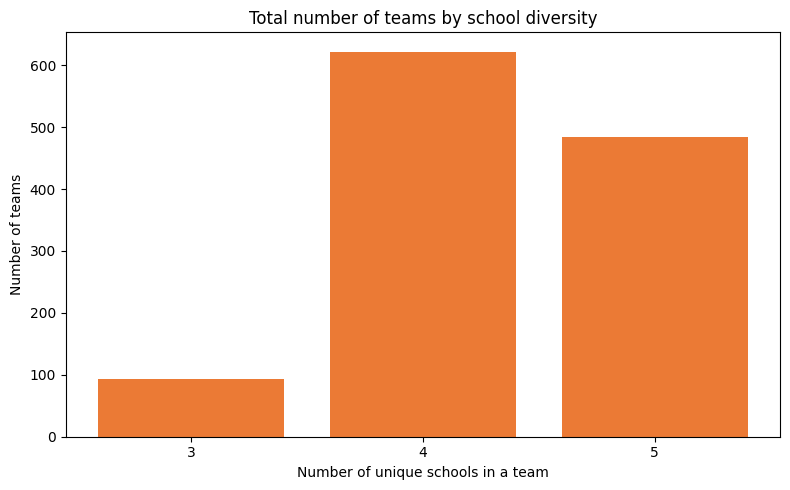

Team Diversity Outcome:
3 unique schools: 94 teams , (7.8%)
4 unique schools: 622 teams , (51.8%)
5 unique schools: 484 teams , (40.3%)


In [ ]:
# Count the number of unique schools in each team
team_diversity_counts = {}
for team_key, students in students_by_team.items():
  unique_schools = set(student[2] for student in students)
  count_unique = len(unique_schools)
  # Increase the count of diversity by 1
  team_diversity_counts[count_unique] = team_diversity_counts.get(count_unique, 0) +1

# Set the x-axis and y-axis variables, aka diversity levels and count of diversity levels
diversity_levels = sorted(team_diversity_counts.keys())
counts = [team_diversity_counts[level] for level in diversity_levels]

# Plot the diversity count and set the dimensions
fig, ax = plt.subplots(figsize = (8,5))
ax.bar(diversity_levels, counts, color = "#eb7a35")

# Create the x-axis, y-axis, title, x-ticks, and bars
ax.set_xlabel("Number of unique schools in a team")
ax.set_ylabel("Number of teams")
ax.set_title("Total number of teams by school diversity")
ax.set_xticks(diversity_levels)

# Display the plot
plt.tight_layout()
plt.show()

# Print and count the length of each bar
total_team_count = sum(counts)
print("Team Diversity Outcome:")
for level, count in zip(diversity_levels, counts):
  percentages = (count/total_team_count) * 100
  print(f"{level} unique schools: {count} teams , ({percentages:.1f}%)")

From the bar chart, we see that every team has students from at least 3 different schools. Over 90% of the teams have students from at least 4 dfifferent schools. And in more than 40% of our teams, every student comes from a different school respectively.

### **Micro view**

For the schools, we will make a stacked barchart to visualise the diversity of the schools within each team of a tutorial group. While a pie chart may make more sense, it is hard to look at 10 pie charts at once. Hence, we will be going for a stacked bar chart. Just as before, we have created a distinct color palette to make each school appear more distinct.

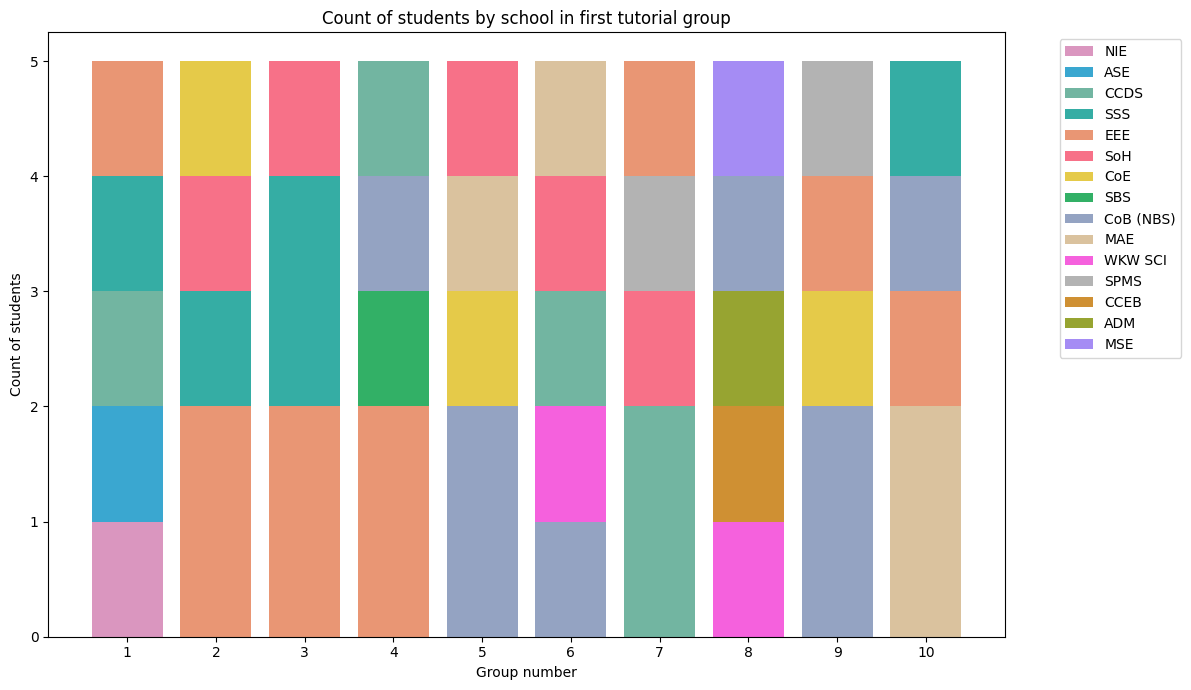

In [ ]:
# Specific color palette for each school
colours = {
    "EEE": "#e99674",
    "CoB (NBS)": "#94a3c2",
    "NIE": "#da96bf",
    "CoE": "#e5ca49",
    "CCDS": "#72b5a1",
    "MAE": "#dac29e",
    "SPMS": "#b3b3b3",
    "SoH": "#f77188",
    "CCEB": "#cf9033",
    "ADM": "#97a431",
    "SBS": "#32b066",
    "SSS": "#35ada4",
    "ASE": "#3aa7d0",
    "MSE": "#a58cf4",
    "WKW SCI": "#f561dd",
}

# Create the stacked bar chart
fig, ax = plt.subplots(figsize = (12,7))
# Create the x-axis and its positions for each group
group_indices = range(1, len(groups) + 1)
plotted_schools = set()


# Loop through each team in the tutorial group by counting how many schools
for group_i, group in enumerate(groups):
  school_counter = {}
  for student in group:
    school = student[2]
    school_counter[school] = school_counter.get(school, 0) + 1

  # Sort the schools with more than 1 student first, followed by those with 1
  school_sorter = sorted(school_counter.items(), key = lambda x:(0 if x[1] > 1 else 1))

  # Stack the bar charts
  bottoms = 0
  for school, count in school_sorter:
    color = colours.get(school, "#666666")
    label = school if school not in plotted_schools else ""
    ax.bar(group_indices[group_i], count , bottom = bottoms, color = color, label = label)
    bottoms += count
    plotted_schools.add(school)

# Add the x-axis, y-axis, title, and x-ticks
ax.set_xlabel("Group number")
ax.set_ylabel("Count of students")
ax.set_title("Count of students by school in first tutorial group")
ax.set_xticks(group_indices)
ax.set_xticklabels([str(t) for t in teams])


# Display the plot and create legend with unique schools
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



Based on the stacked bar chart, and as expected from our macro analysis. At least 9 out of the 10 groups are represented by at least 4 different schools. The groups with multiple students from the same school mainly come from the schools which intrinsically had large student bodies, such as EEE, MAE and CoB(NBS).

## **DIVERSITY OF GENDERS**

We will now likewise view a top-down and bottom-up approach of the distribution of genders across our groups

### **Macro view**

To view the overall distribution of genders. We will count the number of males and females per team, and sum up how many teams in total have X amount of each gender respectively. Given that each team is made up of 5 students. We should see that the number of Males is equal to the 5 minus the number of Females respectively.  

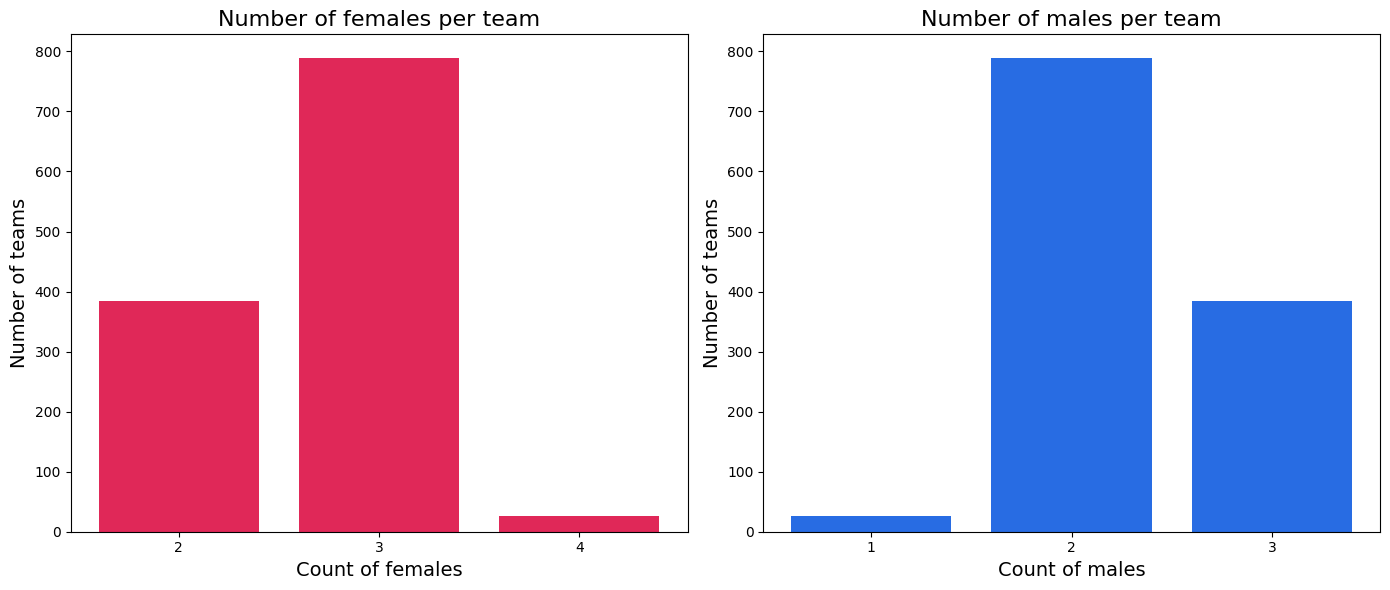

Number of females in a team
2 females: 385 teams (32.1%)
3 females: 789 teams (65.8%)
4 females: 26 teams (2.2%)
Number of males in a team
1 males : 26 teams (2.2%)
2 males : 789 teams (65.8%)
3 males : 385 teams (32.1%)


In [ ]:
female_diversity_counter = {}
male_diversity_counter = {}

# Count the number of females and males per team
for students in students_by_team.values():
  number_females = sum(1 for student in students if student[3].lower() == "female")
  number_males = sum(1 for student in students if student[3].lower() == "male")
  female_diversity_counter[number_females] = female_diversity_counter.get(number_females,0)+1
  male_diversity_counter[number_males] = male_diversity_counter.get(number_males,0) + 1

female_levels = sorted(female_diversity_counter.keys())
male_levels = sorted(male_diversity_counter.keys())

female_counter = [female_diversity_counter[k] for k in female_levels]
male_counter = [male_diversity_counter[k] for k in male_levels]

# Create two columns of charts so as to represent the male/female count next to each other
fig ,axes = plt.subplots(ncols = 2, figsize = (14,6))

# Plot for female counts per team
axes[0].bar(female_levels, female_counter, color='#e02858')

# Label the title, x-axis, y-axis and x-ticks
axes[0].set_title("Number of females per team", fontsize = 16)
axes[0].set_xlabel("Count of females", fontsize = 14)
axes[0].set_ylabel("Number of teams", fontsize = 14)
axes[0].set_xticks(female_levels)

# Plot for male counts per team
axes[1].bar(male_levels, male_counter, color='#286ce3')

# Label the title, x-axis, y-axis and x-ticks
axes[1].set_title("Number of males per team" , fontsize = 16)
axes[1].set_xlabel("Count of males", fontsize = 14)
axes[1].set_ylabel("Number of teams", fontsize = 14)
axes[1].set_xticks(male_levels)

# Improve layout to prevent overlap
plt.tight_layout()
# Display the plot
plt.show()

# Print and count the length of each bar
print("Number of females in a team")
for level, count in zip(female_levels, female_counter):
  percentage = (count/total_team_count) * 100
  print(f"{level} females: {count} teams ({percentage:.1f}%)")

print("Number of males in a team")
for level, count in zip(male_levels, male_counter):
  percentage = (count/ total_team_count) * 100
  print(f"{level} males : {count} teams ({percentage:.1f}%)")


From the graph, we see an asymmetric relationship between the number of males and females per team. Moreover, we see that majority of the team have 3 Females and 2 Males, but also a significant number of groups have 3 Males and 2 Females respectively. Overall, there is a healthy mix of genders among 98% of the groups, with the exception of a small anomaly of groups with 4 Females and 1 Male

### **Micro view**

Looking at one specific tutorial group now, we will see the distribution of Males and Females within each team respectively. From the previous macro view, we should expect to see that most groups will have 2 to 3 Males and Females respectively. To do this, we will sort through each group number and iterate a count loop to get the number of males and females, before setting up a bar chart

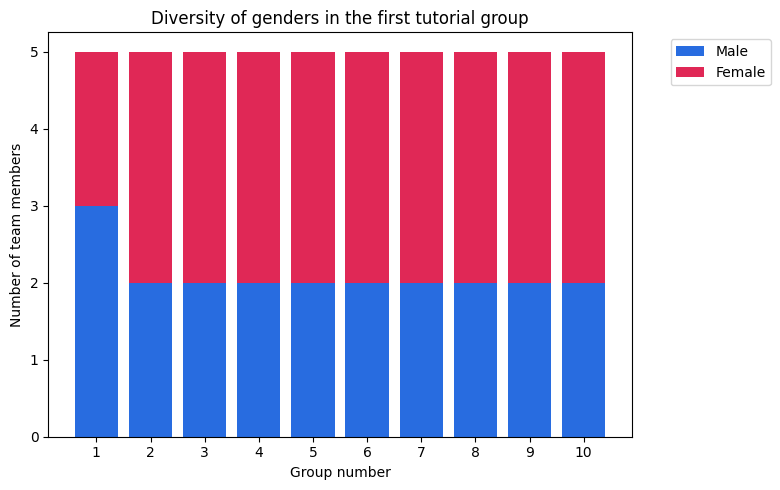

In [ ]:
# Create the bar charts
fig, ax = plt.subplots(figsize = (8, 5))
group_number = [i+1 for i in range(len(groups))]

# Calculate the number of males and females in each group
gender_counter = {"male":[] , "female" : []}
for group in groups:
  male_counter = sum(1 for student in group if student[3].lower() =="male")
  female_counter = sum(1 for student in group if student[3].lower() == "female")
  gender_counter['male'].append(male_counter)
  gender_counter["female"].append(female_counter)

# Initialise the bottoms and define the gender color as before
bottoms = [0.0] * len(group_number)
colors ={ "male": "#286ce0", "female": "#e02856" }

# Plot the stacked bar chart
for gender in ["male", "female"]:
  count = gender_counter[gender]
  ax.bar(group_number, count, label = gender.capitalize() , bottom = bottoms, color = colors[gender])
  bottoms = [bottoms[i] + count[i] for i in range(len(count))]

# Create the title, x-axis, y-axis, xticks, and legend
ax.set_title("Diversity of genders in the first tutorial group")
ax.set_xlabel("Group number")
ax.set_ylabel("Number of team members")
ax.set_xticks(group_number)
ax.set_xticklabels(group_number)
ax.legend(loc = "upper right" , bbox_to_anchor=(1.25,1))

# Display the plot
plt.tight_layout()
plt.show()

From the table, almost every group  has an even distribution of genders. And as expected from before the analysis, we see that most groups have one more female than male. In this particular group, there were more females overall, which is why we didn't see any anomalies or as many groups with 3 males(and 2 females)

## **DIVERSITY OF GPA**

To analyse the diversity of GPA, we will look at a normal distribution of every team's GPA, followed by taking a closer look at an individual tutorial group.

### **Macro view**

To look at the distribution of GPA, we will take a look at the sum of mean GPA of each individual team, regardless of their tutorial, and create a random variable to represent the distribution of the mean GPAs. This will involve calculating the mean and standard deviations as well. To make a normal distribution curve, we will need to set up the parameters of the histogram and the probability density functiona s well to ensure that the curves are smooth and we have an accurate number of bins and frequencies


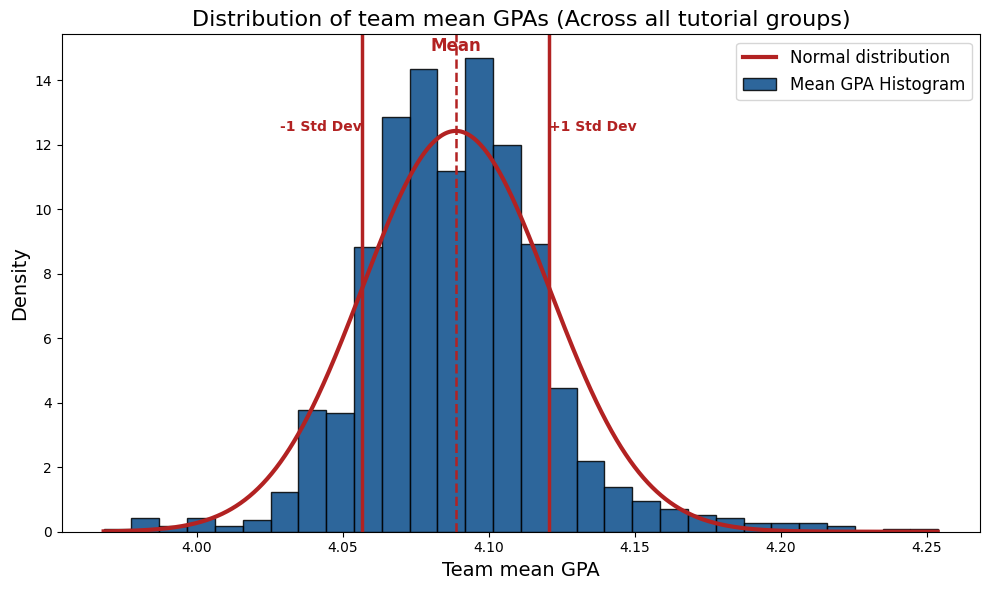

Mean GPA statistics for all teams:
Mean GPA: 4.089
GPA minus one standard deviation: 4.057
GPA plus one standard deviation: 4.121
Standard deviation: 0.032
Total team count: 1200
Teams within 1 standard deviation of the mean: 910 (75.8%)


In [ ]:
# Calculate the mean GPA per team
team_mean_gpas = []
for students in students_by_team.values():
  gpas = [student[4] for student in students]     # Get the GPA values of all students within the same team
  if gpas:
    mean_gpa = sum(gpas) / len(gpas)
    team_mean_gpas.append(mean_gpa)

# Calculate mean and standard deviation of the team mean GPAs
mean = sum(team_mean_gpas) / len(team_mean_gpas)
variance = sum((x-mean) ** 2 for x in team_mean_gpas) / len(team_mean_gpas)
stddev = math.sqrt(variance)

# Set up the parameters of the histogram including total bins and GPA range
number_of_bins = 30
minimum_gpa, maximum_gpa = min(team_mean_gpas), max(team_mean_gpas)
width_of_bin = (maximum_gpa - minimum_gpa) / number_of_bins
bins = [minimum_gpa + i * width_of_bin for i in range(number_of_bins + 1)]
histogram_counts = [0] * number_of_bins

# Count the frequency of each histogram bin
for gpa in team_mean_gpas:
  bin_index = int((gpa - minimum_gpa) / width_of_bin)
  if bin_index == number_of_bins:
    bin_index -= 1
  histogram_counts[bin_index] += 1

# Normalise histogram to forma probability density function
total = sum(histogram_counts)
density = [count / (total * width_of_bin) for count in histogram_counts]

# Prepare smooth points along the normal curve
curve_x = []
curve_y = []
step = width_of_bin / 50
x = minimum_gpa
while x<= maximum_gpa:
  exponent = math.exp(- ((x - mean)**2) / (2 * stddev**2))
  y = (1 / (stddev * math.sqrt(2 * math.pi))) * exponent
  curve_x.append(x)
  curve_y.append(y)
  x += step



# Plot setup
center_bins = [(bins[i] + bins[i + 1]) / 2 for i in range(number_of_bins)]
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the histaogram bars to show the mean GPA distribution
ax.bar(center_bins, density, width = width_of_bin, alpha=0.85, color = '#084B8A',
       edgecolor = 'black', label = 'Mean GPA Histogram')

# Plot the normal distribution curve on top of the histogram
ax.plot(curve_x, curve_y, linewidth = 3, color ='#B22222', label = 'Normal distribution')

# Add red vertical lines for the mean & standard deviation
ax.axvline(mean, color = '#B22222', linestyle='--', linewidth=1.8)
ax.axvline(mean - stddev, color = '#B22222', linestyle = 'solid', linewidth = 2.5)
ax.axvline(mean + stddev, color = '#B22222', linestyle = 'solid', linewidth = 2.5)

# Annotations with text labels to indicate meaning of the lines
ax.text(mean, max(curve_y)*1.20, 'Mean', color ='#B22222',
        fontsize = 12, fontweight ='bold', ha = 'center')
ax.text(mean - stddev, max(curve_y)*1, '-1 Std Dev', color = '#B22222',
        fontsize = 10, fontweight ='bold', ha = 'right')
ax.text(mean + stddev, max(curve_y)*1, '+1 Std Dev', color = '#B22222',
        fontsize = 10, fontweight ='bold',  ha = 'left')

# Set the plot title and x-axis, y-axis
ax.set_title('Distribution of team mean GPAs (Across all tutorial groups)', fontsize=16, )
ax.set_xlabel('Team mean GPA', fontsize = 14)
ax.set_ylabel('Density', fontsize = 14)
ax.legend(fontsize = 12)

# Display the plot
plt.tight_layout()
plt.show()

# Print out the GPA statistics:
minus_one_stddev = mean - stddev
plus_one_stddev = mean + stddev

teams_within_one_sttddev = sum(1 for gpa in team_mean_gpas if minus_one_stddev <= gpa<=plus_one_stddev)
percentage_within_one_stddev = (teams_within_one_sttddev / len(team_mean_gpas)) * 100

print("Mean GPA statistics for all teams:")
print(f"Mean GPA: {mean:.3f}")
print(f"GPA minus one standard deviation: {minus_one_stddev:.3f}")
print(f"GPA plus one standard deviation: {plus_one_stddev:.3f}")
print(f"Standard deviation: {stddev:.3f}")
print(f"Total team count: {len(team_mean_gpas)}")
print(f"Teams within 1 standard deviation of the mean: {teams_within_one_sttddev} ({percentage_within_one_stddev:.1f}%)")

From the above chart, we can see a bimodal distribution curve with two peaks at GPAs of 4.05 and 4.12 respectively. Over 75% of the groups also lie within one standard deviation of the mean GPA which is calculated at around 4.09. There are a few anomalies, with some groups having GPAs of 4.25 to 4.35. This is because of some students having exceptionally high GPAs like 4.4 and 4.6 respectively. That said, the rest of the teammates with high GPA students were still able to bring down their average.

### **Micro view**

Now we will look at one particular tutorial group with their exact GPAs and their respective distribution. We should not use a normal distribution curve because 10 teams is too small of a sample size to get an accurate measure

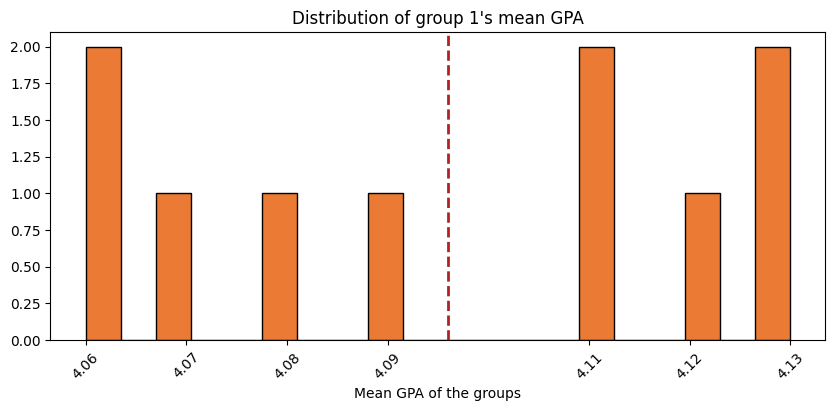

Average GPA in Group 1: 4.096


In [ ]:
# Calculate mean GPA per group
mean_gpas = []
for group in groups:
  gpas = [student[4] for student in group]             # Extract the GPA of each student in the group
  mean_gpa = sum(gpas) / len(gpas) if gpas else 0      # Calculate mean GPA for the group if not empty, else 0
  mean_gpas.append(round(mean_gpa , 2))                # Round mean GPA to 2 decimal places and add to list

# Calculate the mean GPA in this tutorial group
average_GPA_group_1 = sum(mean_gpas)/ len(mean_gpas) if mean_gpas else 0

# Get unique mean GPA values, sorted for x-tick
unique_mean_values = sorted(set(mean_gpas))

# Plot histogram of mean GPAs
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(mean_gpas, bins=20, color='#eb7a34', edgecolor='black')

# We add a vertical line to show the overall average of the group
ax.axvline(average_GPA_group_1, color = "#B22222", linestyle = "--", linewidth = 2.0)

# Set the title and x-axis
ax.set_title("Distribution of group 1's mean GPA")
ax.set_xlabel("Mean GPA of the groups")

# Set x-ticks with rotation to avoid overlap
ax.set_xticks(unique_mean_values)
ax.set_xticklabels([str(val) for val in unique_mean_values], rotation=45)

# Display the plot
plt.show()

# Output the average GPA in group 1
print(f"Average GPA in Group 1: {average_GPA_group_1}")


From the bar chart, we also see that most groups end up with a GPA of around 4.06 to 4.13. Which is similar to the distribution of the CGPAs across the entire student population. Most of the groups have GPAs belong to either peaks of 4.09 and 4.12 respectively. Generally, we can expect to see more of these groups that are within the same range otherwise. We would not expect to see the reverse where there are anomalous groups with average GPAs far below 4.00 for example

# **Challenges and issues faced**

**1. Trade-offs between priotities**

The school diversity optimization stage which runs after gender and CGPA balancing was largely constrained by strict swap conditions to preserve the already-achieved gender and CGPA balance.

This created situations where optimal school diversity was difficult to achieve without compromising the higher-priority factors


**2. Computational Efficiency**

The bubble sort algorithm used for CGPA ordering has O(n²) time complexity, while functional for our dataset of 6000 students, is not optimal for scability. More efficient sorting algorithms such as merge sort can be considered for larger datasets

**3. GPA Variance**

Among the three diversity factors, CGPA proved to be the most challenging. While our analysis showed that most teams achieved mean GPAs clustering close to overall student population mean, some teams exhibited variance from the tutorial group mean that exceeded our ideal targets.

Our alternating strategy had some limitations such as

1) Distribution irregularities
* Later teams may get "leftover" students after early teams pick from the extremes, limiting balancing opportunities
* Some teams inevitably deviate from the mean because of the discrete nature of available GPAs

2) Gender Constraint Interference
* Males and females are sorted by CGPA separately
* We must alternate between male and female lists for gender balance
* This means we cannot always select the true "lowest" or "highest" CGPA available

Ultimately, CGPA variance is inherent to our approach as explained above and represents a practical trade-off in our multi-objective optimization of gender, school diversity and CGPA.





# **CONCLUSION**

Overall, the algorithm we have created, while not perfect, has quite reasonable error rates (primarily only in GPA), all groups have a good balance of genders/schools, with most having a GPA very close the the tutorial group mean. The project has helped us develop our computational thinking processes and deepened our understanding to create and develop a solution to a problem.